In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import iqr
plt.rcParams["figure.figsize"] = (5,3)
student_alc = pd.read_csv("../ZDatasets/student-alcohol-consumption.csv", index_col=0)

# Explanatory Data Analysis
The process of reviweing and cleaning data to
- derive insights
- generate hypotheses

In [34]:
# Inspect the dataset
student_alc.head()

,school,sex,age,famsize,Pstatus,Medu,Fedu,traveltime,failures,schoolsup,...,goout,Dalc,Walc,health,absences,G1,G2,G3,location,study_time
0,GP,F,18,GT3,A,4,4,2,0,yes,...,4,1,1,3,6,5,6,6,Urban,2 to 5 hours
1,GP,F,17,GT3,T,1,1,1,0,no,...,3,1,1,3,4,5,5,6,Urban,2 to 5 hours
2,GP,F,15,LE3,T,1,1,1,3,yes,...,2,2,3,3,10,7,8,10,Urban,2 to 5 hours
3,GP,F,15,GT3,T,4,2,1,0,no,...,2,1,1,5,2,15,14,15,Urban,5 to 10 hours
4,GP,F,16,GT3,T,3,3,1,0,no,...,2,1,2,5,4,6,10,10,Urban,2 to 5 hours


## 1. First Look
### 1.1 Gathering more info

In [40]:
student_alc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 395 entries, 0 to 394
Data columns (total 29 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   famsize     395 non-null    object
 4   Pstatus     395 non-null    object
 5   Medu        395 non-null    int64 
 6   Fedu        395 non-null    int64 
 7   traveltime  395 non-null    int64 
 8   failures    395 non-null    int64 
 9   schoolsup   395 non-null    object
 10  famsup      395 non-null    object
 11  paid        395 non-null    object
 12  activities  395 non-null    object
 13  nursery     395 non-null    object
 14  higher      395 non-null    object
 15  internet    395 non-null    object
 16  romantic    395 non-null    object
 17  famrel      395 non-null    int64 
 18  freetime    395 non-null    int64 
 19  goout       395 non-null    int64 
 20  Dalc        395

### 1.2 Closer look at categorical columns

In [ ]:
# value_counts of 'location'
student_alc['location'].value_counts()

location
Urban    307
Rural     88
Name: count, dtype: int64

### 1.3 Closer look at numerical columns

In [43]:
# Count, Mean, Std, Min, 25-75% percentile, max of the whole dataset
student_alc.describe()

,age,Medu,Fedu,traveltime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


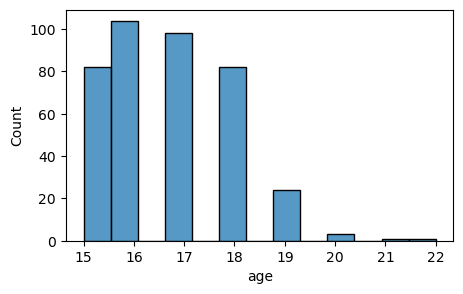

In [ ]:
### 1.4 Visualising numerical data to understnad their distribution (normal, skewed)
sns.histplot(data = student_alc, x = 'age') # bins or binwidth adjustable
plt.show()

## 1.2 Data validation

### 1.2.1 Validating data types

In [58]:
student_alc.dtypes

school        object
sex           object
age            int64
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
traveltime     int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
location      object
study_time    object
dtype: object

#### Updating data types

In [60]:
student_alc[['sex','schoolsup']] = student_alc[['sex','schoolsup']].astype('category')
student_alc[['sex','schoolsup']].dtypes

sex          category
schoolsup    category
dtype: object

### 1.2.2 Validating categorical data

## n. Finding outliers

We subset the column for values under the data - 1.5 * iqr and above the data + 1.5 * iqr threshold.

In [ ]:
iqr = iqr(student_alc['age'])
lower_threshold = np.quantile(student_alc['age'], 0.25) - 1.5 * iqr
upper_threshold = np.quantile(student_alc['age'], 0.75) + 1.5 * iqr
student_alc[(student_alc['age'] < lower_threshold) | (student_alc['age'] > upper_threshold)]

# Alternatively: student['age'].describe()

,school,sex,age,famsize,Pstatus,Medu,Fedu,traveltime,failures,schoolsup,...,goout,Dalc,Walc,health,absences,G1,G2,G3,location,study_time
247,GP,M,22,GT3,T,3,1,1,3,no,...,5,5,5,1,16,6,8,8,Urban,<2 hours
